In [1]:
from tensorflow.keras.datasets import imdb
import numpy as np

In [2]:
vocab_size = 10000
(X_train,y_train), (X_test,y_test) = imdb.load_data(num_words=vocab_size)

In [3]:
print("Train Size:",len(X_train))
print("Test Size:",len(X_test))

Train Size: 25000
Test Size: 25000


In [4]:
print("Positive:",np.sum(y_train))
print("Negative:", len(y_train) - np.sum(y_train))

Positive: 12500
Negative: 12500


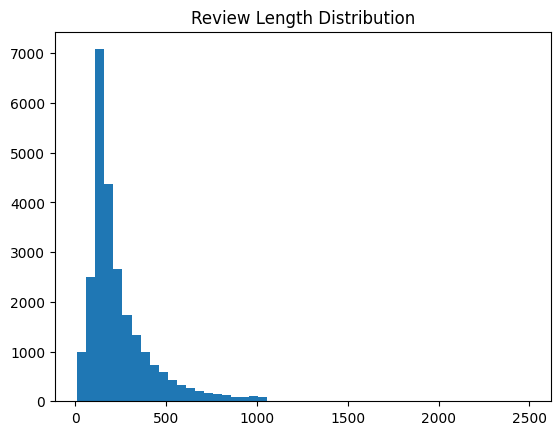

Average length: 238.71364


In [5]:
import matplotlib.pyplot as plt
review_lengths = [len(review) for review in X_train]
plt.hist(review_lengths,bins=50)
plt.title("Review Length Distribution")
plt.show()
print("Average length:",np.mean(review_lengths))

In [6]:
word_index = imdb.get_word_index()
reverse_word_index =  {v:k for k,v in word_index.items()}
decoded = " ".join(
    reverse_word_index.get(i-3,"?") for i in X_train[0]
)
print(decoded)

? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you thi

In [7]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_len = 200
X_train_pad = pad_sequences(X_train,maxlen=max_len)
X_test_pad = pad_sequences(X_test,maxlen=max_len)
print(X_train_pad.shape)

(25000, 200)


In [8]:
def decode_review(sequence):
    return " ".join(reverse_word_index.get(i-3,"?") for i in sequence)
X_train_text = [decode_review(seq) for seq in X_train]
X_test_text = [decode_review(seq) for seq in X_test]

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf,y_train)
preds = lr.predict(X_test_tfidf)
print("TF-IDF and LR score",accuracy_score(y_test,preds))

TF-IDF and LR score 0.884


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense

model = Sequential([
    Embedding(vocab_size,128,input_length=max_len),
    LSTM(64),
    Dense(1,activation='sigmoid')
])
model.compile(
    optimizer='adam',loss='binary_crossentropy',
    metrics=["accuracy"]
)
model.fit(X_train_pad,y_train,epochs=5,batch_size=64,validation_split=0.2)

Epoch 1/5
313/313 [==============================] - 114s 348ms/step - loss: 0.4520 - accuracy: 0.7794 - val_loss: 0.3349 - val_accuracy: 0.8626
Epoch 2/5
313/313 [==============================] - 114s 364ms/step - loss: 0.2568 - accuracy: 0.8975 - val_loss: 0.3236 - val_accuracy: 0.8592
Epoch 3/5
313/313 [==============================] - 114s 364ms/step - loss: 0.1781 - accuracy: 0.9343 - val_loss: 0.3477 - val_accuracy: 0.8672
Epoch 4/5
313/313 [==============================] - 107s 342ms/step - loss: 0.1261 - accuracy: 0.9564 - val_loss: 0.3873 - val_accuracy: 0.8546
Epoch 5/5
313/313 [==============================] - 116s 370ms/step - loss: 0.1111 - accuracy: 0.9625 - val_loss: 0.4264 - val_accuracy: 0.8662


In [12]:
model.evaluate(X_train_pad,y_test)

782/782 [==============================] - 53s 68ms/step - loss: 2.6976 - accuracy: 0.4953


[2.6975555419921875, 0.49531999230384827]

In [13]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [14]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [15]:
encodings = tokenizer(
    X_test_text,
    truncation=True,
    padding=True,
    max_length=200,
)

In [16]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased",num_labels=2)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [17]:
train_encodings = tokenizer(X_train_text,truncation=True,padding=True,max_length=200)
test_encodings = tokenizer(X_test_text,truncation=True,padding=True,max_length=200)

In [18]:
import torch

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(self.encodings[key][idx]) for key in self.encodings}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [19]:
train_dataset = IMDBDataset(train_encodings, y_train)
test_dataset = IMDBDataset(test_encodings, y_test)

In [20]:
from transformers import Trainer, TrainingArguments
training_args = TrainingArguments(
    output_dir = './results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
)

In [21]:
import transformers
print(transformers.__version__)
print(TrainingArguments)

4.53.1
<class 'transformers.training_args.TrainingArguments'>


In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    precision, recall, f1,_ = precision_recall_fscore_support(
    labels,preds,average="binary"
    )
    acc = accuracy_score(labels,preds)
    return {
    "accuracy":acc,
    "f1":f1,
    "precision":precision,
    "recall":recall
    }

In [23]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

C:\Users\Shraddha\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
